In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

sys.version_info(major=3, minor=12, micro=10, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.2
pandas 3.0.0
sklearn 1.8.0
torch 2.6.0+cu124
cuda:0


In [3]:
import os
import requests

# 定义下载地址和保存路径
url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
file_name = "shakespeare.txt"

# 如果文件不存在，则下载
if not os.path.exists(file_name):
    print(f"正在从 {url} 下载...")
    response = requests.get(url)
    with open(file_name, "w", encoding="utf-8") as f:
        f.write(response.text)
    print("下载完成！")
else:
    print("文件已存在，无需下载。")

# 读取并测试
with open(file_name, "r", encoding="utf-8") as f:
    text = f.read()

print(f"全文字数: {len(text)}")
print("-" * 30)
print(text[:100])


文件已存在，无需下载。
全文字数: 1115394
------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [4]:
# https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt
#文件已经下载好了
with open("./shakespeare.txt", "r", encoding="utf8") as file:
    text = file.read()

print("length", len(text))
print(text[0:100])

length 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [5]:
# 1. generate vocab
# 2. build mapping char->id
# 3. data -> id_data  把数据都转为id
# 4. a b c d [EOS] -> [BOS] b c d  预测下一个字符生成的模型，也就是输入是a，输出就是b

#去重，留下独立字符，并排序
vocab = sorted(set(text))
print(len(vocab))
print(vocab)

65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [6]:
#每个字符都编好号，enumerate对每一个位置编号，生成的是列表中是元组，下面字典生成式
char2idx = {char:idx for idx, char in enumerate(vocab)}
print(char2idx)

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


In [7]:
# 把vocab从列表变为ndarray
idx2char = np.array(vocab)
print(idx2char)

['\n' ' ' '!' '$' '&' "'" ',' '-' '.' '3' ':' ';' '?' 'A' 'B' 'C' 'D' 'E'
 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W'
 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o'
 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [8]:
#把字符都转换为id
text_as_int = np.array([char2idx[c] for c in text])
print(text_as_int.shape)
print(len(text_as_int))
print(text_as_int[0:10])
print(text[0:10])

(1115394,)
1115394
[18 47 56 57 58  1 15 47 58 47]
First Citi


In [9]:
from torch.utils.data import Dataset, DataLoader

class CharDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        self.sub_len = seq_length + 1
        self.text_as_int = text_as_int
        self.num_seq = len(text_as_int) // self.sub_len

    def __getitem__(self, index):
        return self.text_as_int[index * self.sub_len: (index + 1) * self.sub_len]

    def __len__(self):
        return self.num_seq

def collat_fct(batch):
    src_list = []
    trg_list = []
    for part in batch:
        src_list.append(part[:-1])
        trg_list.append(part[1:])

    src_list = np.array(src_list)
    trg_list = np.array(trg_list)
    return torch.Tensor(src_list).to(dtype=torch.int64), torch.Tensor(trg_list).to(dtype=torch.int64)


train_ds = CharDataset(text_as_int, 100)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collat_fct)

In [10]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)
        x = self.fc(output)
        return x, hidden


vocab_size = len(vocab)
sample_inputs = torch.randint(0, vocab_size, (2, 100))

print("{:=^80}".format(" 一层单向 LSTM "))
for key, value in CharLSTM(vocab_size).named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

CharLSTM(vocab_size)(sample_inputs)[0].shape

================================== 一层单向 LSTM ===================================
            embedding.weight            paramerters num: 16640
           lstm.weight_ih_l0            paramerters num: 1048576
           lstm.weight_hh_l0            paramerters num: 4194304
            lstm.bias_ih_l0             paramerters num: 4096
            lstm.bias_hh_l0             paramerters num: 4096
               fc.weight                paramerters num: 66560
                fc.bias                 paramerters num: 65


torch.Size([2, 100, 65])

In [11]:
model = CharLSTM(vocab_size)

# 计算总参数量
total_params = sum(p.numel() for p in model.parameters())

# 计算可训练参数量（通常两者相等，除非你冻结了某些层）
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 5,334,337
Trainable Parameters: 5,334,337


In [12]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [13]:
# 训练
def training(
    model,
    train_loader,
    epoch,
    loss_fct,
    optimizer,
    save_ckpt_callback=None,
    stateful=False      # 想用stateful，batch里的数据就必须连续，不能打乱
    ):
    record_dict = {
        "train": [],
    }

    global_step = 0
    model.train()
    hidden = None
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算
                logits, hidden = model(datas, hidden=hidden if stateful else None)
                # 计算损失
                loss = loss_fct(logits.reshape(-1, vocab_size), labels.reshape(-1))
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()

                loss = loss.cpu().item()
                # record

                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # 保存模型权重 save model checkpoint
                if save_ckpt_callback is not None:
                    save_ckpt_callback(global_step, model.state_dict(), metric=-loss)
                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict


epoch = 100

model = CharLSTM(vocab_size=vocab_size)

# 1. 定义损失函数 采用交叉熵损失
loss_fct = nn.CrossEntropyLoss()
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# save best
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback("checkpoints/text_generation_lstm", save_step=1000, save_best_only=True)


model = model.to(device)
record = training(
    model,
    train_dl,
    epoch,
    loss_fct,
    optimizer,
    save_ckpt_callback=save_ckpt_callback,
    )

  0%|          | 0/17300 [00:00<?, ?it/s]

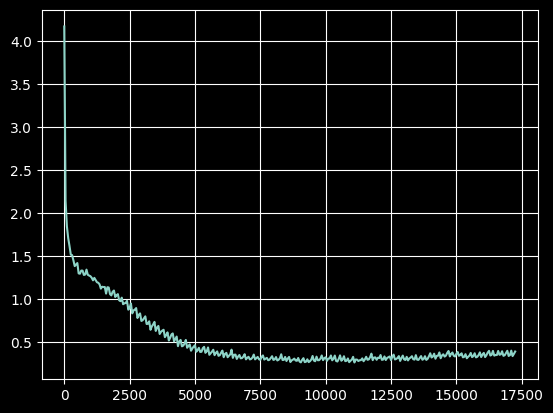

In [14]:
plt.plot([i["step"] for i in record["train"][::50]], [i["loss"] for i in record["train"][::50]], label="train")
plt.grid()
plt.show()

In [15]:
def generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True):
    input_eval = torch.Tensor([char2idx[char] for char in start_string]).to(dtype=torch.int64, device=device).reshape(1, -1)
    hidden = None
    text_generated = []
    model.eval()
    pbar = tqdm(range(max_len))
    print(start_string, end="")
    with torch.no_grad():
        for i in pbar:
            logits, hidden = model(input_eval, hidden=hidden)
            # 温度采样
            logits = logits[0, -1, :] / temperature
            # using multinomial to sampling
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, 1).item()
            input_eval = torch.Tensor([idx]).to(dtype=torch.int64, device=device).reshape(1, -1)
            text_generated.append(idx)
            if stream:
                print(idx2char[idx], end="", flush=True)
    return "".join([idx2char[i] for i in text_generated])


torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# load checkpoints
model.load_state_dict(torch.load("checkpoints/text_generation_lstm/best.ckpt", map_location="cpu"))
start_string = "All: "
res = generate_text(model, start_string, max_len=1000, temperature=0.5, stream=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

All: what a flower-ouble sentence?

ABHORSON:
At the other shows a son of mine own.

PRINCE EDWARD:
An if I live until I be a man,
If heaven is himself an honest what is death:
O, he being sued to fear the love! and there
comes comes by cords with his thing. O, pear Margaret,
Say that she might through the death of my money-hard
When thou didst constant to this work nor night
Than I desire to love, and would have slain
I cannot choose but knowledge this most noble
Till use my body that may be made a fool
I spake on means to colour my person:
'Tis death to make thee spare my father.

GLOUCESTER:
Touch'd you the measure of a woman's war,
The very minute of this second match,
Plant were ends, if I had been my heart:
Therefore, to break that Henry,--

Fourtherly were I will discover a brace of breath;
I was a prize that love them govern men.
But leave me soldiers than earth, and not
the auttier of ungrate that e'er I nursed:
Nay, then is my sovereign, but welcome us
To think but one of the

以下是理解temperature

In [20]:
import torch
import math

def manual_softmax_with_temperature(logits, temperature):
    print(f"--- 计算过程 (T={temperature}) ---")

    # 1. 缩放 (Logits / T)
    scaled_logits = [x / temperature for x in logits]
    print(f"1. 缩放后: {scaled_logits}")

    # 2. 指数化 (exp)
    exps = [math.exp(x) for x in scaled_logits]
    print(f"2. 指数化: {exps}")

    # 3. 求和 (sum)
    sum_exps = sum(exps)
    print(f"3. 求和值: {sum_exps}")

    # 4. 归一化 (probability)
    probs = [x / sum_exps for x in exps]
    return probs

# 定义数据
logits_list = [0.4, 0.6]

# 验证 T=1
result_t1 = manual_softmax_with_temperature(logits_list, temperature=1.0)
print(f"最终结果 T=1: {result_t1}\n")

# 验证 T=2
result_t2 = manual_softmax_with_temperature(logits_list, temperature=2.0)
print(f"最终结果 T=2: {result_t2}")

--- 计算过程 (T=1.0) ---
1. 缩放后: [0.4, 0.6]
2. 指数化: [1.4918246976412703, 1.8221188003905089]
3. 求和值: 3.3139434980317795
最终结果 T=1: [0.4501660026875221, 0.5498339973124778]

--- 计算过程 (T=2.0) ---
1. 缩放后: [0.2, 0.3]
2. 指数化: [1.2214027581601699, 1.3498588075760032]
3. 求和值: 2.5712615657361733
最终结果 T=2: [0.47502081252106, 0.5249791874789399]


以下是multinomial的理解

In [21]:
import torch

# 1. 设定概率分布 (也就是“胜率”)
# 比如：索引0是 20%，索引1是 80%
weights = torch.tensor([0.2, 0.8], dtype=torch.float)

print(f"--- 设定的概率: {weights} ---")

# 2. 进行一次采样 (模拟一次抽奖)
# num_samples=1 表示抽一次
# replacement=True 表示抽完放回（通常用于生成文本）
sample_one = torch.multinomial(weights, num_samples=1, replacement=True)
print(f"抽一次的结果索引: {sample_one.item()}")
# (这里可能是0，也可能是1，但大概率是1)


# 3. 大规模采样验证原理 (抽 10000 次)
print("\n--- 开始抽样 10,000 次以验证原理 ---")
samples_many = torch.multinomial(weights, num_samples=10000, replacement=True)

# 统计 0 出现了多少次，1 出现了多少次
count_0 = (samples_many == 0).sum().item()
count_1 = (samples_many == 1).sum().item()

print(f"索引 0 出现的次数: {count_0} (约占 {count_0/10000:.2%})")
print(f"索引 1 出现的次数: {count_1} (约占 {count_1/10000:.2%})")

# 预期结果：
# 索引 0 应该接近 2000 次 (20%)
# 索引 1 应该接近 8000 次 (80%)

--- 设定的概率: tensor([0.2000, 0.8000]) ---
抽一次的结果索引: 1

--- 开始抽样 10,000 次以验证原理 ---
索引 0 出现的次数: 1933 (约占 19.33%)
索引 1 出现的次数: 8067 (约占 80.67%)


以下是对lstm的理解

In [22]:
import torch

# 1. 模拟向量 B (信息流 - Information)
# 图中数据: [13.8, 14, -7, -4, 30.0]
vector_B = torch.tensor([13.8, 14.0, -7.0, -4.0, 30.0])

# 2. 模拟向量 A 的原始输入 (Logits)
# 为了得到图中的 [0.1, 0.9...],我们需要反推Sigmoid前的输入，
# 但这里我们直接定义经过Sigmoid后的门控值来模拟图中情景
# 图中数据: [0.1, 0.9, 0.4, 0.0, 0.6]
gate_values = torch.tensor([0.1, 0.9, 0.4, 0.0, 0.6])

# 在真实的神经网络中，gate_values 通常是这样计算出来的:
# vector_A_raw = 神经网络层的输出(x)
# vector_A = torch.sigmoid(vector_A_raw)

# 3. 执行门限机制 (逐元素乘法)
# A * B
output = gate_values * vector_B

print("向量 A (门限/比例):", gate_values)
print("向量 B (原始信息):", vector_B)
print("-" * 30)
print("A * B (最终保留的信息):", output)

# 对比图中结果: [1.38, 12.6, -2.8, 0, 18.0]

向量 A (门限/比例): tensor([0.1000, 0.9000, 0.4000, 0.0000, 0.6000])
向量 B (原始信息): tensor([13.8000, 14.0000, -7.0000, -4.0000, 30.0000])
------------------------------
A * B (最终保留的信息): tensor([ 1.3800, 12.6000, -2.8000, -0.0000, 18.0000])


In [23]:
import torch
import torch.nn as nn

# 假设我们在处理一个简单的 LSTM 步骤
input_size = 5  # 输入特征维度
hidden_size = 5 # 隐藏层/门控维度

# 1. 定义线性层 (相当于神经网络学到的权重 W 和 b)
# 这一步负责计算“原始分数”
linear_layer = nn.Linear(input_size + hidden_size, hidden_size)

# 模拟数据
current_input = torch.randn(1, input_size)    # 当前输入 x_t
prev_hidden   = torch.randn(1, hidden_size)   # 上一步记忆 h_{t-1}

# 拼接输入 (将 x_t 和 h_{t-1} 连在一起)
combined_input = torch.cat((current_input, prev_hidden), dim=1)

# --- 核心生成步骤 ---

# 步骤 1: 线性计算 (得到原始分数 z)
# 这里的数值可能是任何数，比如 5.2 或 -12.4
raw_scores_z = linear_layer(combined_input)
print(f"1. 原始分数 (z): \n{raw_scores_z.detach().numpy()}")

# 步骤 2: Sigmoid 激活 (生成向量 A)
# 这里应用截图中的公式: 1 / (1 + e^-z)
vector_A = torch.sigmoid(raw_scores_z)
print(f"\n2. Sigmoid 生成的向量 A (门限): \n{vector_A.detach().numpy()}")

# 观察结果:
# 你会发现 vector_A 中的所有数字都在 0.0 到 1.0 之间。
# 原始分数越大，A 越接近 1；原始分数越小，A 越接近 0。

1. 原始分数 (z): 
[[-0.40536705 -0.25529185  0.06263465  0.2822054  -0.06526893]]

2. Sigmoid 生成的向量 A (门限): 
[[0.40002355 0.43652144 0.51565355 0.57008684 0.4836885 ]]
